In [ ]:
"""
Synthetic Student Performance Dataset Generator

creates a realistic dataset of student behavior and academic performance.
We use synthetic data because:
No real student data exists yet (we're building the collection system)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set random seed for reproducibility
# This ensures everyone gets the same "random" numbers
np.random.seed(42)

# Dataset size
NUM_STUDENTS = 1000

print("=" * 60)
print("SYNTHETIC DATASET GENERATION")
print("=" * 60)
print(f"\nGenerating data for {NUM_STUDENTS} synthetic students...\n")

# Generate Independent Features (Student Behaviors)

print("Step 1: Generating behavioral features...")

# Feature 1: Total weekly study hours
# Most students study 10-20 hours/week, with some outliers
# Using normal distribution: mean=15, std=5
study_hours = np.random.normal(loc=15, scale=5, size=NUM_STUDENTS)
study_hours = np.clip(study_hours, 2, 40)  # Realistic bounds: 2-40 hours/week

# Feature 2: Average session length (minutes)
# Most sessions are 30-90 minutes
# Longer sessions generally indicate better focus
avg_session_length = np.random.normal(loc=60, scale=20, size=NUM_STUDENTS)
avg_session_length = np.clip(avg_session_length, 15, 180)

# Feature 3: Study sessions per week
# Most students have 5-15 sessions per week
# Calculated from total hours and session length
study_sessions_per_week = (study_hours * 60) / avg_session_length
study_sessions_per_week = np.clip(study_sessions_per_week, 2, 25)

# Feature 4: Focus ratio (0-1 scale)
# % of study time without distractions
# Beta distribution: skewed toward higher focus (most students try to focus)
focus_ratio = np.random.beta(a=5, b=2, size=NUM_STUDENTS)
focus_ratio = np.clip(focus_ratio, 0.3, 0.98)

# Feature 5: Late-night study ratio (0-1 scale)
# % of study time after 10 PM
# Most students don't study late, but some do (skewed toward low)
late_night_ratio = np.random.beta(a=2, b=5, size=NUM_STUDENTS)
late_night_ratio = np.clip(late_night_ratio, 0, 0.8)

# Feature 6: Days until deadline (average)
# How early students start assignments
# Lower = more procrastination
days_until_deadline = np.random.gamma(shape=3, scale=2, size=NUM_STUDENTS)
days_until_deadline = np.clip(days_until_deadline, 0.5, 14)

# Feature 7: Video completion rate (0-1 scale)
# % of educational videos watched completely
# Beta distribution: many students either finish or quit early
video_completion_rate = np.random.beta(a=4, b=2, size=NUM_STUDENTS)
video_completion_rate = np.clip(video_completion_rate, 0.2, 1.0)

# Feature 8: Practice problem attempts (per week)
# Active learning indicator
# Gamma distribution: most do a few, some do many
practice_attempts = np.random.gamma(shape=2, scale=8, size=NUM_STUDENTS)
practice_attempts = np.clip(practice_attempts, 0, 50)

# Feature 9: Forum participation (posts per week)
# Engagement with learning community
# Most students don't post much (Poisson-like)
forum_participation = np.random.poisson(lam=2, size=NUM_STUDENTS)
forum_participation = np.clip(forum_participation, 0, 15)

# Feature 10: Study streak (consecutive days)
# Consistency indicator
# Gamma distribution: some students very consistent, others sporadic
study_streak = np.random.gamma(shape=3, scale=4, size=NUM_STUDENTS)
study_streak = np.clip(study_streak, 1, 30)

print("All 10 behavioral features generated")


SYNTHETIC DATASET GENERATION

Generating data for 1000 synthetic students...

Step 1: Generating behavioral features...
All 10 behavioral features generated


In [ ]:
# Define Relationships (Features → Grade)
print("\nCalculating grades based on behaviors...")

# Base grade: Everyone starts at 30
# This represents baseline ability without any study effort
base_grade = 30

# Initialize grade array
final_grade = np.full(NUM_STUDENTS, base_grade, dtype=float)

# Apply feature weights (based on educational research insights)
# These are tuned to create realistic grade distribution (mean ~70, pass rate ~75%)

# Positive contributors
final_grade += study_hours * 1.2              # More study = better grades
final_grade += focus_ratio * 18               # Focus matters a lot
final_grade += (avg_session_length / 60) * 2  # Longer sessions help
final_grade += video_completion_rate * 10     # Finishing videos shows engagement
final_grade += np.sqrt(practice_attempts) * 2  # Diminishing returns on practice
final_grade += np.log1p(forum_participation) * 2.5  # Some engagement helps
final_grade += (study_streak / 30) * 8        # Consistency bonus
final_grade += days_until_deadline * 0.5      # Early starters do better

# Negative contributors
final_grade -= late_night_ratio * 15          # Late-night studying hurts retention
final_grade -= (study_sessions_per_week > 20) * 8  # Too many short sessions = inefficient


Calculating grades based on behaviors...


In [ ]:
# Add Realistic Noise
print("Adding noise to simulate real-world variance...")

# Noise represents factors we can't measure:
# - Test anxiety
# - Personal life events
# - Luck on exam questions
# - Teaching quality
# - Prior knowledge
noise = np.random.normal(loc=0, scale=7, size=NUM_STUDENTS)
final_grade += noise

# Clip grades to realistic bounds (0-100)
final_grade = np.clip(final_grade, 0, 100)

# Round to 1 decimal place (like real grades)
final_grade = np.round(final_grade, 1)

print(f"Grade distribution: mean={final_grade.mean():.1f}, std={final_grade.std():.1f}")

# Create Binary Target (Pass/Fail)
print("\nCreating pass/fail labels...")

# Pass threshold: 60%
PASS_THRESHOLD = 60
pass_fail = (final_grade >= PASS_THRESHOLD).astype(int)

pass_rate = (pass_fail.sum() / NUM_STUDENTS) * 100
print(f"Pass rate: {pass_rate:.1f}% ({pass_fail.sum()}/{NUM_STUDENTS} students)")

Adding noise to simulate real-world variance...
Grade distribution: mean=79.5, std=10.2

Creating pass/fail labels...
Pass rate: 96.9% (969/1000 students)


In [66]:
#Create DataFrame
print("\nBuilding dataset...")

# Create the dataset
data = pd.DataFrame({
    # Features (10 behavioral signals)
    'total_study_hours': study_hours,
    'avg_session_length': avg_session_length,
    'study_sessions_per_week': study_sessions_per_week,
    'focus_ratio': focus_ratio,
    'late_night_study_ratio': late_night_ratio,
    'days_until_deadline_avg': days_until_deadline,
    'video_completion_rate': video_completion_rate,
    'practice_problem_attempts': practice_attempts,
    'forum_participation': forum_participation,
    'study_streak_days': study_streak,
    
    # Targets
    'final_grade': final_grade,
    'pass_fail': pass_fail
})

# Round numeric columns for cleaner display
data = data.round({
    'total_study_hours': 1,
    'avg_session_length': 1,
    'study_sessions_per_week': 1,
    'focus_ratio': 3,
    'late_night_study_ratio': 3,
    'days_until_deadline_avg': 1,
    'video_completion_rate': 3,
    'practice_problem_attempts': 0,
    'forum_participation': 0,
    'study_streak_days': 0
})

print(f"Dataset shape: {data.shape}")
print(f"  - {data.shape[0]} students (rows)")
print(f"  - {data.shape[1]} columns (10 features + 2 targets)")


Building dataset...
Dataset shape: (1000, 12)
  - 1000 students (rows)
  - 12 columns (10 features + 2 targets)


In [68]:
# Check correlation with target (sanity check)
print("\nTop 5 features correlated with final grade:")
correlations = data.corr()['final_grade'].drop('final_grade').sort_values(ascending=False)
print(correlations.head())


Top 5 features correlated with final grade:
pass_fail                    0.410262
total_study_hours            0.366986
focus_ratio                  0.286759
avg_session_length           0.256778
practice_problem_attempts    0.218261
Name: final_grade, dtype: float64


In [69]:
#Save the dataset
print("\nSaving dataset...")

output_file = 'student_performance_data.csv'
data.to_csv(output_file, index=False)
print(f"saved to: {output_file}")


Saving dataset...
saved to: student_performance_data.csv



Creating visualizations...


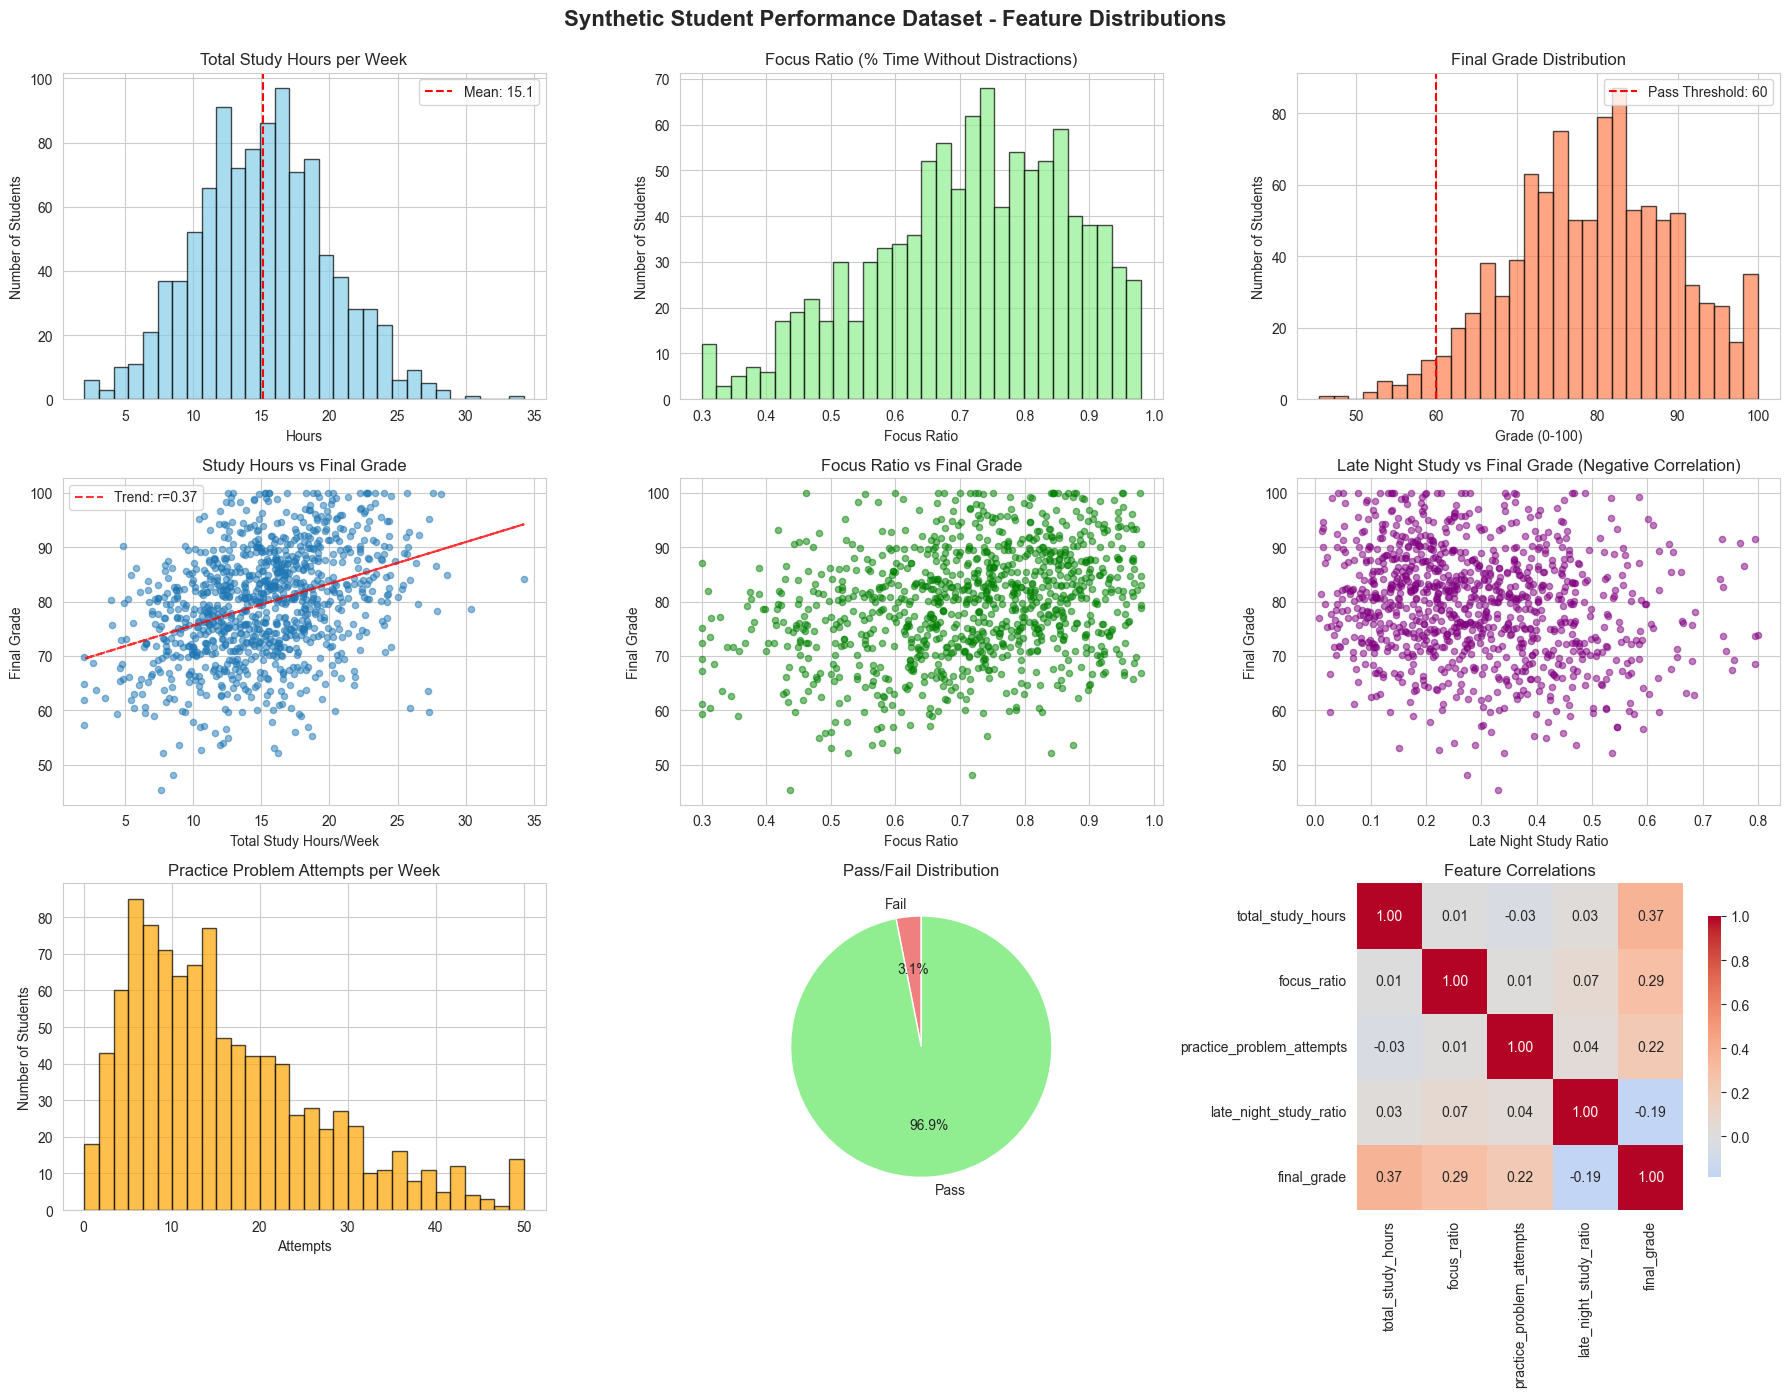

In [ ]:
#generate visualizations
print("\nCreating visualizations...")

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

# Create a 3x3 subplot grid
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Synthetic Student Performance Dataset - Feature Distributions', 
             fontsize=16, fontweight='bold', y=0.995)

# Plot 1: Study hours distribution
axes[0, 0].hist(study_hours, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 0].set_title('Total Study Hours per Week')
axes[0, 0].set_xlabel('Hours')
axes[0, 0].set_ylabel('Number of Students')
axes[0, 0].axvline(study_hours.mean(), color='red', linestyle='--', label=f'Mean: {study_hours.mean():.1f}')
axes[0, 0].legend()

# Plot 2: Focus ratio distribution
axes[0, 1].hist(focus_ratio, bins=30, edgecolor='black', alpha=0.7, color='lightgreen')
axes[0, 1].set_title('Focus Ratio (% Time Without Distractions)')
axes[0, 1].set_xlabel('Focus Ratio')
axes[0, 1].set_ylabel('Number of Students')

# Plot 3: Final grade distribution
axes[0, 2].hist(final_grade, bins=30, edgecolor='black', alpha=0.7, color='coral')
axes[0, 2].set_title('Final Grade Distribution')
axes[0, 2].set_xlabel('Grade (0-100)')
axes[0, 2].set_ylabel('Number of Students')
axes[0, 2].axvline(PASS_THRESHOLD, color='red', linestyle='--', label=f'Pass Threshold: {PASS_THRESHOLD}')
axes[0, 2].legend()

# Plot 4: Study hours vs Grade (scatter)
axes[1, 0].scatter(study_hours, final_grade, alpha=0.5, s=20)
axes[1, 0].set_title('Study Hours vs Final Grade')
axes[1, 0].set_xlabel('Total Study Hours/Week')
axes[1, 0].set_ylabel('Final Grade')
# Add trend line
z = np.polyfit(study_hours, final_grade, 1)
p = np.poly1d(z)
axes[1, 0].plot(study_hours, p(study_hours), "r--", alpha=0.8, label=f'Trend: r={np.corrcoef(study_hours, final_grade)[0,1]:.2f}')
axes[1, 0].legend()

# Plot 5: Focus ratio vs Grade (scatter)
axes[1, 1].scatter(focus_ratio, final_grade, alpha=0.5, s=20, color='green')
axes[1, 1].set_title('Focus Ratio vs Final Grade')
axes[1, 1].set_xlabel('Focus Ratio')
axes[1, 1].set_ylabel('Final Grade')

# Plot 6: Late night study vs Grade (scatter)
axes[1, 2].scatter(late_night_ratio, final_grade, alpha=0.5, s=20, color='purple')
axes[1, 2].set_title('Late Night Study vs Final Grade (Negative Correlation)')
axes[1, 2].set_xlabel('Late Night Study Ratio')
axes[1, 2].set_ylabel('Final Grade')

# Plot 7: Practice attempts distribution
axes[2, 0].hist(practice_attempts, bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[2, 0].set_title('Practice Problem Attempts per Week')
axes[2, 0].set_xlabel('Attempts')
axes[2, 0].set_ylabel('Number of Students')

# Plot 8: Pass/Fail pie chart
pass_counts = data['pass_fail'].value_counts().sort_index()
labels = ['Fail', 'Pass'] if len(pass_counts) == 2 else (['Fail'] if 0 in pass_counts.index else ['Pass'])
colors_map = {0: 'lightcoral', 1: 'lightgreen'}
colors = [colors_map[idx] for idx in pass_counts.index]
axes[2, 1].pie(pass_counts, labels=labels, autopct='%1.1f%%', 
               colors=colors, startangle=90)
axes[2, 1].set_title('Pass/Fail Distribution')

# Plot 9: Correlation heatmap (top features)
top_features = ['total_study_hours', 'focus_ratio', 'practice_problem_attempts', 
                'late_night_study_ratio', 'final_grade']
corr_matrix = data[top_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, ax=axes[2, 2], cbar_kws={'shrink': 0.8})
axes[2, 2].set_title('Feature Correlations')

plt.tight_layout()

In [71]:
print("\nDataset Summary:")
print(data.describe().round(2))


Dataset Summary:
       total_study_hours  avg_session_length  study_sessions_per_week  \
count            1000.00             1000.00                  1000.00   
mean               15.10               61.52                    15.46   
std                 4.88               19.68                     6.20   
min                 2.00               15.00                     2.00   
25%                11.78               47.88                    10.60   
50%                15.10               61.25                    14.80   
75%                18.20               74.62                    20.62   
max                34.30              123.90                    25.00   

       focus_ratio  late_night_study_ratio  days_until_deadline_avg  \
count      1000.00                 1000.00                  1000.00   
mean          0.71                    0.29                     5.91   
std           0.15                    0.16                     3.11   
min           0.30                    0.